# Notebook 04_B: SHAP Explanations

This notebook explains the frozen final Random Forest model from Notebook 03_C.

### Locked SHAP design

- SHAP is calculated for **all 24 predictors**.
- Global SHAP explains which predictors generally influence the model.
- Local SHAP keeps **all 24 feature contributions** for every student predicted as at risk.
- No arbitrary top 5, top 10, or percentage cutoff is used for the intervention layer.
- Positive local SHAP values will be used in Notebook 05 as evidence supporting proposed intervention options.
- Negative local SHAP values are retained because they are part of the complete explanation, but they do not trigger intervention support.
- The operational risk probability comes from the calibrated final model.
- Tree SHAP explains the underlying fitted Random Forest before calibration.


## 1. Imports and paths

In [1]:
from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse
import shap

TOP_GLOBAL = 15

CURRENT_DIR = Path.cwd()
PROJECT_DIR = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR
DATA_DIR = PROJECT_DIR / "data" / "processed" / "ml_ready"
MODEL_DIR = PROJECT_DIR / "results" / "final_model"
OUTPUT_DIR = PROJECT_DIR / "results" / "explainability"
FIGURES_DIR = PROJECT_DIR / "results" / "figures"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

c:\Users\israa.tajaldin\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load the frozen model and held out test data

In [2]:
final_model = joblib.load(MODEL_DIR / "final_calibrated_model.joblib")

with open(MODEL_DIR / "final_model_metadata.json", "r", encoding="utf-8") as file:
    metadata = json.load(file)

X_test = pd.read_pickle(DATA_DIR / "X_test_raw.pkl")
y_test = pd.read_pickle(DATA_DIR / "y_test.pkl")

FINAL_THRESHOLD = float(metadata["final_threshold"])
RAW_FEATURES = list(metadata["selected_features"])

assert len(RAW_FEATURES) == 24
assert list(X_test.columns) == RAW_FEATURES

print("Final model:", metadata["final_model"])
print("Final threshold:", FINAL_THRESHOLD)
print("Test students:", len(X_test))
print("Raw predictors:", len(RAW_FEATURES))

Final model: Random Forest
Final threshold: 0.29
Test students: 752
Raw predictors: 24


## 3. Final calibrated risk predictions

The calibrated probability is the final operational risk probability.

A student is classified as at risk when the calibrated risk probability is greater than or equal to the frozen final threshold.

In [3]:
risk_probability = final_model.predict_proba(X_test)[:, 1]
predicted_label = (risk_probability >= FINAL_THRESHOLD).astype(int)

predictions = pd.DataFrame({
    "case_id": [f"TEST_CASE_{i + 1:04d}" for i in range(len(X_test))],
    "actual_label": np.asarray(y_test).astype(int),
    "predicted_label": predicted_label,
    "predicted_risk_probability": risk_probability,
})

print("Predicted at risk students:", int(predicted_label.sum()))

Predicted at risk students: 225


## 4. Calculate Tree SHAP values

The calibrated model is used for the reported risk probability.

Tree SHAP is applied to the underlying fitted Random Forest because it directly explains the fitted tree model.

In [4]:
calibrated_classifier = final_model.calibrated_classifiers_[0]

base_pipeline = getattr(calibrated_classifier, "estimator", None)
if base_pipeline is None:
    base_pipeline = getattr(calibrated_classifier, "base_estimator", None)

preprocessor = base_pipeline.named_steps["preprocessor"]
random_forest = base_pipeline.named_steps["model"]

X_prepared = preprocessor.transform(X_test)
if sparse.issparse(X_prepared):
    X_prepared = X_prepared.toarray()

prepared_names = list(preprocessor.get_feature_names_out())

explainer = shap.TreeExplainer(random_forest)
raw_values = explainer.shap_values(X_prepared)

if isinstance(raw_values, list):
    prepared_shap = np.asarray(raw_values[1] if len(raw_values) > 1 else raw_values[0])
else:
    values = np.asarray(raw_values)
    if values.ndim == 2:
        prepared_shap = values
    elif values.ndim == 3 and values.shape[0] == len(X_test):
        prepared_shap = values[:, :, 1]
    elif values.ndim == 3:
        prepared_shap = values[1, :, :]
    else:
        raise ValueError(f"Unexpected SHAP shape: {values.shape}")

expected = np.asarray(explainer.expected_value).reshape(-1)
positive_base_value = float(expected[-1])

print("Prepared SHAP shape:", prepared_shap.shape)
print("Positive class base value:", round(positive_base_value, 6))

Prepared SHAP shape: (752, 36)
Positive class base value: 0.497715


## 5. Aggregate encoded SHAP columns back to the 24 original predictors

Categorical predictors are one hot encoded inside the model pipeline.

Their encoded SHAP contributions are added back together so that all local and global explanations use the original 24 Banner and Moodle predictor names.

In [5]:
CATEGORICAL_FEATURES = [
    "programme_or_school",
    "year_level",
    "previous_academic_standing",
]

def raw_feature_name(prepared_name):
    name = prepared_name.split("__", 1)[-1]
    for feature in CATEGORICAL_FEATURES:
        if name == feature or name.startswith(feature + "_"):
            return feature
    return name

prepared_to_raw = [raw_feature_name(name) for name in prepared_names]
raw_shap = np.zeros((len(X_test), len(RAW_FEATURES)))

for j, feature in enumerate(RAW_FEATURES):
    idx = [i for i, mapped in enumerate(prepared_to_raw) if mapped == feature]
    raw_shap[:, j] = prepared_shap[:, idx].sum(axis=1)

print("Aggregated SHAP shape:", raw_shap.shape)

Aggregated SHAP shape: (752, 24)


## 6. SHAP fidelity check

The SHAP values should reconstruct the underlying Random Forest positive class score.

A very small error confirms that the explanation is numerically consistent with the fitted tree model.

In [6]:
rf_probability = random_forest.predict_proba(X_prepared)[:, 1]
reconstructed = positive_base_value + raw_shap.sum(axis=1)
error = np.abs(reconstructed - rf_probability)

print("Mean reconstruction error:", f"{error.mean():.10f}")
print("Maximum reconstruction error:", f"{error.max():.10f}")

Mean reconstruction error: 0.0000000000
Maximum reconstruction error: 0.0000000000


## 7. Global SHAP importance

In [7]:
global_importance = pd.DataFrame({
    "feature": RAW_FEATURES,
    "mean_absolute_shap": np.abs(raw_shap).mean(axis=0),
    "mean_signed_shap": raw_shap.mean(axis=0),
}).sort_values("mean_absolute_shap", ascending=False).reset_index(drop=True)

display(global_importance.head(TOP_GLOBAL).round(5))

,feature,mean_absolute_shap,mean_signed_shap
0,credits_earned_ratio,0.30163,-0.13508
1,repeated_course_count_current,0.05655,-0.00879
2,previous_cgpa_ordinal,0.03270,-0.00845
3,year_level,0.02451,-0.01170
4,previous_failed_course_count,0.02017,-0.00528
5,previous_term_gpa_ordinal,0.01554,-0.00033
6,programme_or_school,0.01300,-0.00434
7,absence_count,0.00996,-0.00488
8,registered_credits,0.00873,-0.00031
9,total_course_event_clicks,0.00724,-0.00471


## 8. Global SHAP diagrams

Two global views are retained:

- **Bar plot:** overall feature importance.
- **Beeswarm plot:** importance, direction, and distribution across students.

All 24 predictors are evaluated. The plots display the top 15 only for readability.

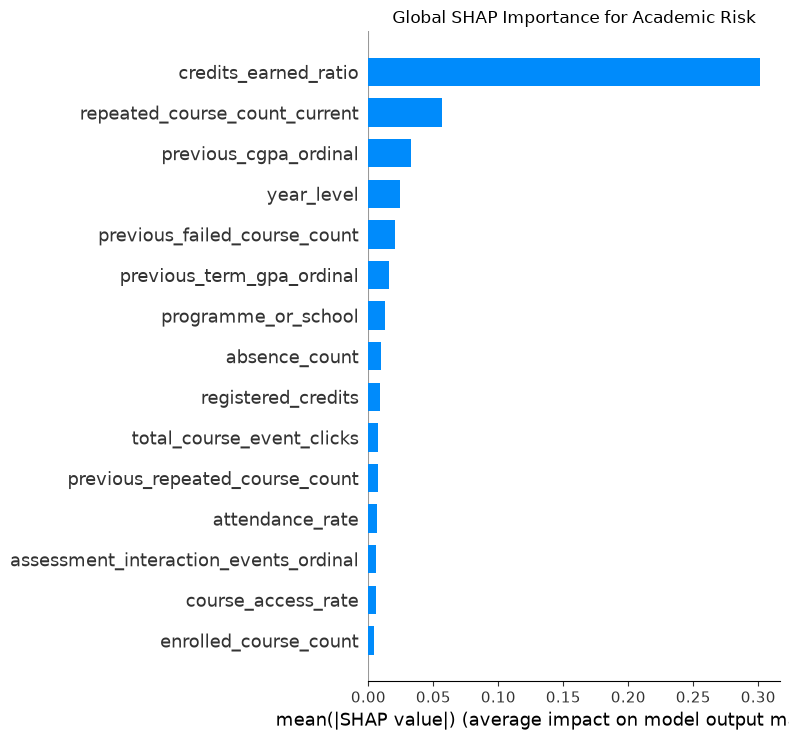

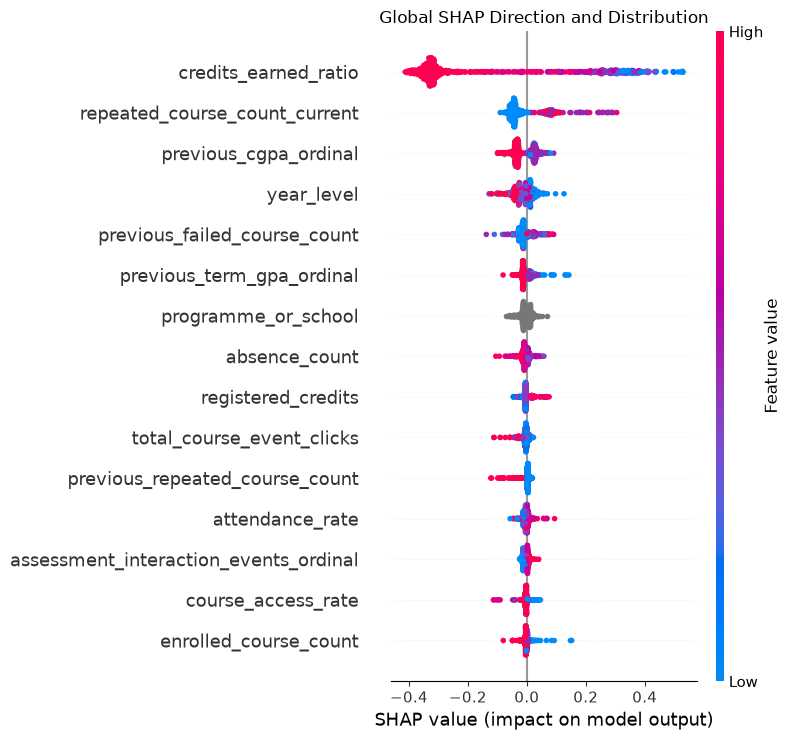

Saved: c:\Users\israa.tajaldin\OneDrive - Bahrain Polytechnic\Group Group IT9099 - Israa Tajaldin - General\04_Project_Notebooks\results\figures\global_shap_importance_bar.png
Saved: c:\Users\israa.tajaldin\OneDrive - Bahrain Polytechnic\Group Group IT9099 - Israa Tajaldin - General\04_Project_Notebooks\results\figures\global_shap_beeswarm.png


In [8]:
shap.summary_plot(
    raw_shap,
    feature_names=RAW_FEATURES,
    plot_type="bar",
    max_display=TOP_GLOBAL,
    show=False,
)
plt.title("Global SHAP Importance for Academic Risk")
plt.tight_layout()
BAR_FILE = FIGURES_DIR / "global_shap_importance_bar.png"
plt.savefig(BAR_FILE, dpi=300, bbox_inches="tight")
plt.show()

shap.summary_plot(
    raw_shap,
    features=X_test[RAW_FEATURES],
    feature_names=RAW_FEATURES,
    max_display=TOP_GLOBAL,
    show=False,
)
plt.title("Global SHAP Direction and Distribution")
plt.tight_layout()
BEESWARM_FILE = FIGURES_DIR / "global_shap_beeswarm.png"
plt.savefig(BEESWARM_FILE, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", BAR_FILE)
print("Saved:", BEESWARM_FILE)

## 9. Save all 24 local SHAP factors for every predicted at risk student

No local feature is discarded.

Each predicted at risk student contributes exactly 24 rows, one for every original predictor.

The saved table contains:

- anonymised case ID,
- calibrated predicted risk probability,
- feature,
- raw feature value,
- SHAP value.

This complete table becomes the input to Notebook 05.

In [9]:
rows = []

for position in np.flatnonzero(predicted_label == 1):
    case_id = f"TEST_CASE_{position + 1:04d}"

    for j, feature in enumerate(RAW_FEATURES):
        rows.append({
            "case_id": case_id,
            "predicted_risk_probability": float(risk_probability[position]),
            "feature": feature,
            "raw_value": X_test.iloc[position][feature],
            "shap_value": float(raw_shap[position, j]),
        })

local_shap_all_factors = pd.DataFrame(rows)

expected_rows = int(predicted_label.sum()) * len(RAW_FEATURES)
assert len(local_shap_all_factors) == expected_rows

print("Predicted at risk students:", int(predicted_label.sum()))
print("Factors per student:", len(RAW_FEATURES))
print("Saved local SHAP rows:", len(local_shap_all_factors))

Predicted at risk students: 225
Factors per student: 24
Saved local SHAP rows: 5400


## 10. Save explanation outputs

In [10]:
PREDICTION_FILE = OUTPUT_DIR / "test_risk_predictions.csv"
GLOBAL_FILE = OUTPUT_DIR / "global_shap_importance.csv"
LOCAL_FILE = OUTPUT_DIR / "at_risk_all_24_shap_factors.csv"

predictions.to_csv(PREDICTION_FILE, index=False)
global_importance.to_csv(GLOBAL_FILE, index=False)
local_shap_all_factors.to_csv(LOCAL_FILE, index=False)

print("Saved:", PREDICTION_FILE)
print("Saved:", GLOBAL_FILE)
print("Saved:", LOCAL_FILE)

Saved: c:\Users\israa.tajaldin\OneDrive - Bahrain Polytechnic\Group Group IT9099 - Israa Tajaldin - General\04_Project_Notebooks\results\explainability\test_risk_predictions.csv
Saved: c:\Users\israa.tajaldin\OneDrive - Bahrain Polytechnic\Group Group IT9099 - Israa Tajaldin - General\04_Project_Notebooks\results\explainability\global_shap_importance.csv
Saved: c:\Users\israa.tajaldin\OneDrive - Bahrain Polytechnic\Group Group IT9099 - Israa Tajaldin - General\04_Project_Notebooks\results\explainability\at_risk_all_24_shap_factors.csv


## Notebook 04_B complete

For every student predicted as at risk:

- all 24 feature values are retained,
- all 24 SHAP values are retained,
- no arbitrary local top k is used.

Notebook 05 will map all 24 factors to the five controlled intervention categories and use positive SHAP contributions to quantify how strongly each intervention category is supported for mentor review.